#**GAN**





#**Part-1**

In [59]:
import torch
from torch import nn
import math
import matplotlib.pyplot as plt
%matplotlib inline
import numpy as np

In [2]:
# Setting a seed for reproducibility.
torch.manual_seed(42)

In [3]:
train_data_length = 1024
train_data = torch.zeros((train_data_length, 2))

train_data[:, 0] = 2.0 * math.pi * torch.rand(train_data_length)
train_data[:, 1] = torch.sin(train_data[:, 0])

train_labels = torch.zeros(train_data_length)
train_set = [(train_data[i], train_labels[i]) for i in range(train_data_length)]

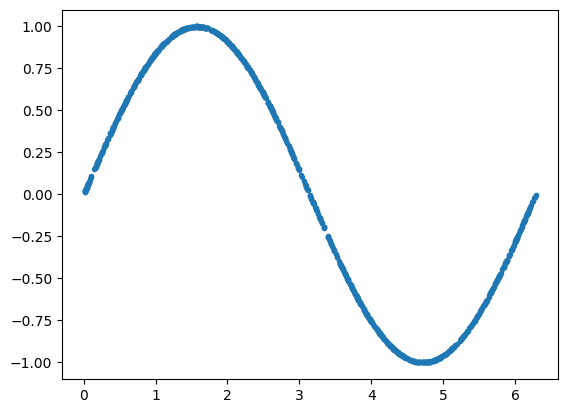

In [4]:
plt.plot(train_data[:, 0], train_data[:, 1], ".")
plt.show()

In [5]:
batch_size = 32
train_loader = torch.utils.data.DataLoader(
    train_set, batch_size=batch_size, shuffle=True)

In [6]:
class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(2, 256),
            nn.ReLU(),  # activation function
            nn.Dropout(0.3),  # dropout to prevent overfitting
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 1),
            nn.Sigmoid(),)  # sigmoid activation to produce a probability


    # Describe how the forward pass is calculated.
    def forward(self, x):
        output = self.model(x)
        return output

In [7]:
# After declaring the discriminator class, we instantiate a discriminator object.
discriminator = Discriminator()

In [8]:
class Generator(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(2, 16),
            nn.ReLU(),
            nn.Linear(16, 32),
            nn.ReLU(),
            nn.Linear(32, 2),)

    def forward(self, x):
        output = self.model(x)
        return output


# Instantiate generator object.
generator = Generator()

In [9]:
lr = 0.001
num_epochs = 2000
loss_function = nn.BCELoss()

In [10]:
optimizer_discriminator = torch.optim.Adam(discriminator.parameters(), lr=lr)
optimizer_generator = torch.optim.Adam(generator.parameters(), lr=lr)

In [11]:
for epoch in range(num_epochs):
    for n, (real_samples, _) in enumerate(train_loader):
        # Data for training the discriminator.
        real_samples_labels = torch.ones((batch_size, 1))
        latent_space_samples = torch.randn((batch_size, 2))
        generated_samples = generator(latent_space_samples)
        generated_samples_labels = torch.zeros((batch_size, 1))
        all_samples = torch.cat((real_samples, generated_samples))
        all_samples_labels = torch.cat((real_samples_labels, generated_samples_labels))

        # Training the discriminator.
        discriminator.zero_grad()
        output_discriminator = discriminator(all_samples)
        loss_discriminator = loss_function(output_discriminator, all_samples_labels)
        loss_discriminator.backward()
        optimizer_discriminator.step()

        # Data for training the generator.
        latent_space_samples = torch.randn((batch_size, 2))

        # Training the generator.
        generator.zero_grad()
        generated_samples = generator(latent_space_samples)
        output_discriminator_generated = discriminator(generated_samples)
        loss_generator = loss_function(
            output_discriminator_generated, real_samples_labels
        )
        loss_generator.backward()
        optimizer_generator.step()

        # Print loss at various training stages.
        print_epoch_num = (
            100  # Change this depending on often the loss should be printed.
        )
        if epoch % print_epoch_num == 0 and n == batch_size - 1:
            print(f"Epoch: {epoch} Loss D.: {loss_discriminator}")
            print(f"Epoch: {epoch} Loss G.: {loss_generator}")

Epoch: 0 Loss D.: 0.10651858150959015
Epoch: 0 Loss G.: 2.6915292739868164
Epoch: 100 Loss D.: 0.6771022081375122
Epoch: 100 Loss G.: 0.7336205840110779
Epoch: 200 Loss D.: 0.6455041170120239
Epoch: 200 Loss G.: 0.883645236492157
Epoch: 300 Loss D.: 0.7510595917701721
Epoch: 300 Loss G.: 0.6410450339317322
Epoch: 400 Loss D.: 0.6402899622917175
Epoch: 400 Loss G.: 0.8643763065338135
Epoch: 500 Loss D.: 0.6194202303886414
Epoch: 500 Loss G.: 1.0063339471817017
Epoch: 600 Loss D.: 0.6766213178634644
Epoch: 600 Loss G.: 0.7338934540748596
Epoch: 700 Loss D.: 0.7163495421409607
Epoch: 700 Loss G.: 0.7215312123298645
Epoch: 800 Loss D.: 0.7765070796012878
Epoch: 800 Loss G.: 0.883323073387146
Epoch: 900 Loss D.: 0.5988984704017639
Epoch: 900 Loss G.: 1.0034375190734863
Epoch: 1000 Loss D.: 0.6808976531028748
Epoch: 1000 Loss G.: 0.6545848250389099
Epoch: 1100 Loss D.: 0.6375536918640137
Epoch: 1100 Loss G.: 0.8529494404792786
Epoch: 1200 Loss D.: 0.6668440103530884
Epoch: 1200 Loss G.: 0.66

In [12]:
# Generate 1000 random 2D points and feed them to the generator.
latent_space_samples = torch.randn(1000, 2)
generated_samples = generator(latent_space_samples)

# Turn the PyTorch tensor into a NumPy array.
generated_samples_numpy = generated_samples.detach().numpy()

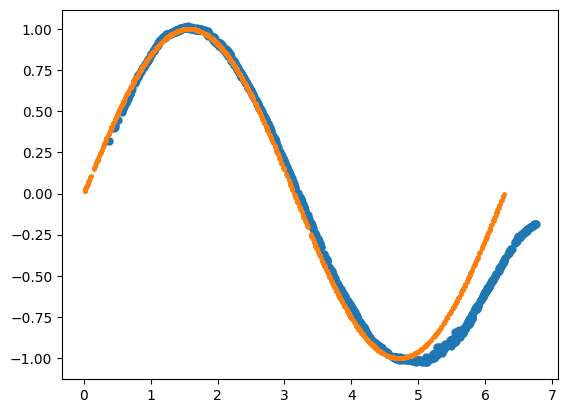

In [13]:
# Plot the generated samples and the original training data.
plt.plot(
    generated_samples_numpy[:, 0], generated_samples_numpy[:, 1], ".", markersize=10)
plt.plot(train_data[:, 0], train_data[:, 1], ".", markersize=5)
plt.show()

In [14]:
class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(2, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 1),
            nn.Sigmoid(),
        )

    def forward(self, x):
        return self.model(x)


class Generator(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(2, 16),
            nn.ReLU(),
            nn.Linear(16, 32),
            nn.ReLU(),
            nn.Linear(32, 2),
        )

    def forward(self, x):
        return self.model(x)

In [15]:
def train_gan(train_set, num_epochs=2000, batch_size=32, lr=0.001, label="GAN"):
    train_loader = torch.utils.data.DataLoader(train_set, batch_size=batch_size, shuffle=True)
    discriminator = Discriminator()
    generator = Generator()
    loss_function = nn.BCELoss()
    opt_d = torch.optim.Adam(discriminator.parameters(), lr=lr)
    opt_g = torch.optim.Adam(generator.parameters(), lr=lr)

    for epoch in range(num_epochs):
        for n,(real_samples, _)in enumerate(train_loader):
            #train discriminator
            real_labels=torch.ones((batch_size,1))
            noise=torch.randn((batch_size,2))
            fake_samples=generator(noise)
            fake_labels=torch.zeros((batch_size,1))

            all_samples=torch.cat((real_samples,fake_samples))
            all_labels=torch.cat((real_labels, fake_labels))

            discriminator.zero_grad()
            output_d=discriminator(all_samples)
            loss_d=loss_function(output_d,all_labels)
            loss_d.backward()
            opt_d.step()

            #train generator
            noise=torch.randn((batch_size,2))
            discriminator.zero_grad()
            generator.zero_grad()
            fake_samples=generator(noise)
            output_d_fake=discriminator(fake_samples)
            loss_g=loss_function(output_d_fake,real_labels)
            loss_g.backward()
            opt_g.step()

        if epoch % 500==0:
            print(f"[{label}]Epoch{epoch:4d}|Loss D:{loss_d.item():.4f}|Loss G:{loss_g.item():.4f}")
    return generator

In [16]:
#gAN 1 — 2D spiral
def make_spiral(n=1024):
    data=torch.zeros((n, 2))
    half=n//2
    # Arm 1
    theta1=torch.linspace(0,4*math.pi,half)
    r1=theta1/(4*math.pi)
    data[:half,0]=r1*torch.cos(theta1)+0.05*torch.randn(half)
    data[:half,1]=r1*torch.sin(theta1)+0.05*torch.randn(half)
    # Arm 2 (rotated 180°)
    theta2=theta1+math.pi
    r2=theta2/(4*math.pi)
    data[half:,0]=r2*torch.cos(theta2)+0.05*torch.randn(half)
    data[half:,1]=r2*torch.sin(theta2)+0.05*torch.randn(half)
    labels=torch.zeros(n)
    return data,[(data[i],labels[i])for i in range(n)]


spiral_data,spiral_set=make_spiral()
print("Training spiral gan")
gen_spiral=train_gan(spiral_set,label="Spiral")

Training spiral gan
[Spiral]Epoch   0|Loss D:0.5208|Loss G:0.9920
[Spiral]Epoch 500|Loss D:0.6787|Loss G:0.7720
[Spiral]Epoch1000|Loss D:0.6651|Loss G:0.7783
[Spiral]Epoch1500|Loss D:0.6569|Loss G:0.6887


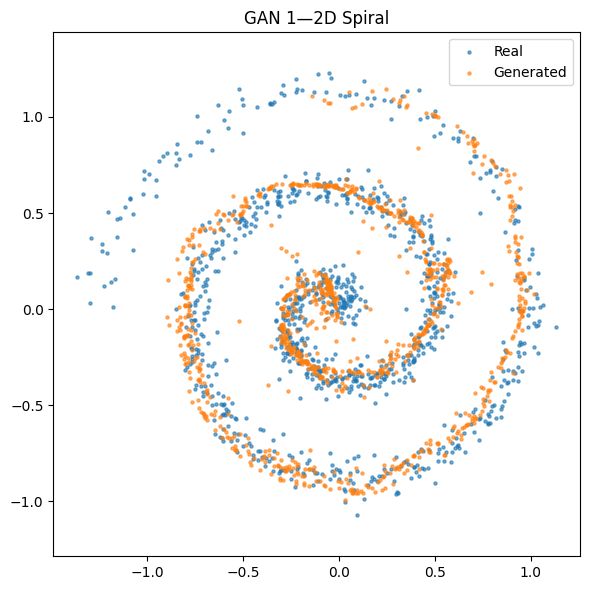

In [17]:
#plot
with torch.no_grad():
    noise = torch.randn(1000, 2)
    gen_spiral_pts=gen_spiral(noise).numpy()
plt.figure(figsize=(6,6))
plt.scatter(spiral_data[:,0], spiral_data[:,1],s=5,label="Real",alpha=0.6)
plt.scatter(gen_spiral_pts[:,0],gen_spiral_pts[:,1],s=5,label="Generated",alpha=0.6)
plt.legend()
plt.title("GAN 1—2D Spiral")
plt.axis("equal")
plt.tight_layout()
plt.savefig("gan1_spiral.png",dpi=120)
plt.show()

In [18]:
# GAN-2noisy parametric curve y = sin(2x) + 0.3cos(5x) + ε
def make_noisy_curve(n=1024):
    data =torch.zeros((n,2))
    data[:,0] =2*math.pi*torch.rand(n)
    data[:,1]=(
        torch.sin(2*data[:,0])
        + 0.3*torch.cos(5*data[:,0])
        + 0.1*torch.randn(n))# ε ~ N(0, 0.1)

    labels=torch.zeros(n)
    return data,[(data[i],labels[i]) for i in range(n)]


curve_data,curve_set=make_noisy_curve()
print("Training parametric urve gan")
gen_curve=train_gan(curve_set,label="Noisy Curve")


Training parametric urve gan
[Noisy Curve]Epoch   0|Loss D:0.3163|Loss G:1.5204
[Noisy Curve]Epoch 500|Loss D:0.6822|Loss G:0.7218
[Noisy Curve]Epoch1000|Loss D:0.6927|Loss G:0.7049
[Noisy Curve]Epoch1500|Loss D:0.6868|Loss G:0.7057


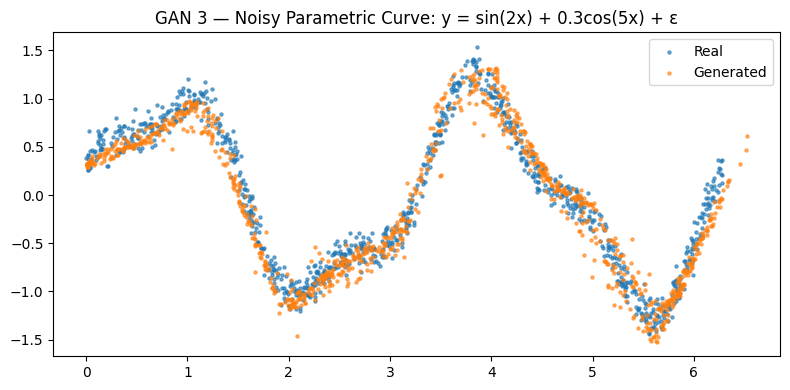

In [19]:
with torch.no_grad():
    noise = torch.randn(1000, 2)
    gen_curve_pts = gen_curve(noise).numpy()

plt.figure(figsize=(8, 4))
plt.scatter(curve_data[:, 0], curve_data[:, 1], s=5, label="Real", alpha=0.6)
plt.scatter(gen_curve_pts[:, 0], gen_curve_pts[:, 1], s=5, label="Generated", alpha=0.6)
plt.legend()
plt.title("GAN 3 — Noisy Parametric Curve: y = sin(2x) + 0.3cos(5x) + ε")
plt.tight_layout()
plt.savefig("gan3_noisy_curve.png", dpi=120)
plt.show()

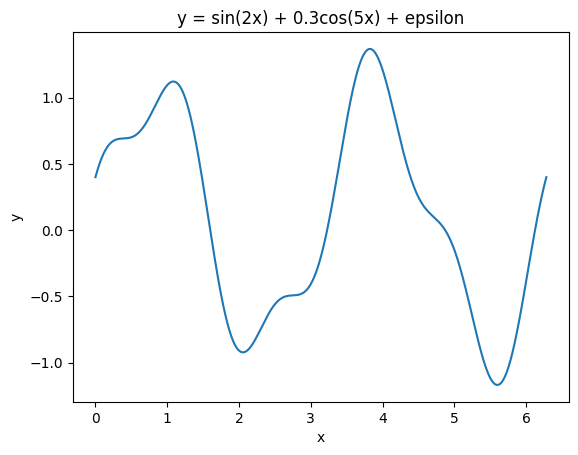

In [20]:
# Parameters
epsilon = 0.1  # you can change this noise level
x = np.linspace(0, 2*np.pi, 1000)
#function
y = np.sin(2*x) + 0.3 * np.cos(5*x) + epsilon
#plot
plt.figure()
plt.plot(x, y)
plt.xlabel("x")
plt.ylabel("y")
plt.title("y = sin(2x) + 0.3cos(5x) + epsilon")
plt.show()

#**Blood Cell**

In [21]:
%pip install medmnist

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 7.7 MB/s eta 0:00:00


In [22]:
#loading data
from medmnist import BloodMNIST
train_dataset = BloodMNIST(split="train", download=True)

100%|██████████| 35.5M/35.5M [00:02<00:00, 12.0MB/s]


In [23]:
from collections import Counter
from medmnist import INFO
from medmnist.dataset import BloodMNIST
import torchvision.transforms as transforms

In [24]:
#load dataset info
info = INFO['bloodmnist']
task = info['task']
n_classes = len(info['label'])
print("Task:", task)
print("Number of classes:", n_classes)
print("Class names:")
for k, v in info['label'].items():
    print(f"{k}: {v}")

Task: multi-class
Number of classes: 8
Class names:
0: basophil
1: eosinophil
2: erythroblast
3: immature granulocytes(myelocytes, metamyelocytes and promyelocytes)
4: lymphocyte
5: monocyte
6: neutrophil
7: platelet


In [25]:
# Load splits
transform = transforms.Compose([transforms.ToTensor(),transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])])
train_dataset = BloodMNIST(split='train', transform=transform, download=True)
val_dataset = BloodMNIST(split='val', transform=transform, download=True)
test_dataset = BloodMNIST(split='test', transform=transform, download=True)

In [26]:
# Convert labels to numpy arrays
train_labels = np.array(train_dataset.labels).squeeze()
val_labels = np.array(val_dataset.labels).squeeze()
test_labels = np.array(test_dataset.labels).squeeze()

In [27]:
# Function to print class distribution
def print_distribution(labels, split_name):
    counter = Counter(labels)
    print(f"\nClass distribution ({split_name}):")
    total = len(labels)
    for cls in sorted(counter.keys()):
        print(f"Class {cls} ({info['label'][str(cls)]}): {counter[cls]} ({counter[cls]/total:.2%})")
print_distribution(train_labels, "train")
print_distribution(val_labels, "val")
print_distribution(test_labels, "test")


Class distribution (train):
Class 0 (basophil): 852 (7.12%)
Class 1 (eosinophil): 2181 (18.24%)
Class 2 (erythroblast): 1085 (9.07%)
Class 3 (immature granulocytes(myelocytes, metamyelocytes and promyelocytes)): 2026 (16.94%)
Class 4 (lymphocyte): 849 (7.10%)
Class 5 (monocyte): 993 (8.30%)
Class 6 (neutrophil): 2330 (19.48%)
Class 7 (platelet): 1643 (13.74%)

Class distribution (val):
Class 0 (basophil): 122 (7.13%)
Class 1 (eosinophil): 312 (18.22%)
Class 2 (erythroblast): 155 (9.05%)
Class 3 (immature granulocytes(myelocytes, metamyelocytes and promyelocytes)): 290 (16.94%)
Class 4 (lymphocyte): 122 (7.13%)
Class 5 (monocyte): 143 (8.35%)
Class 6 (neutrophil): 333 (19.45%)
Class 7 (platelet): 235 (13.73%)

Class distribution (test):
Class 0 (basophil): 244 (7.13%)
Class 1 (eosinophil): 624 (18.24%)
Class 2 (erythroblast): 311 (9.09%)
Class 3 (immature granulocytes(myelocytes, metamyelocytes and promyelocytes)): 579 (16.92%)
Class 4 (lymphocyte): 243 (7.10%)
Class 5 (monocyte): 284 

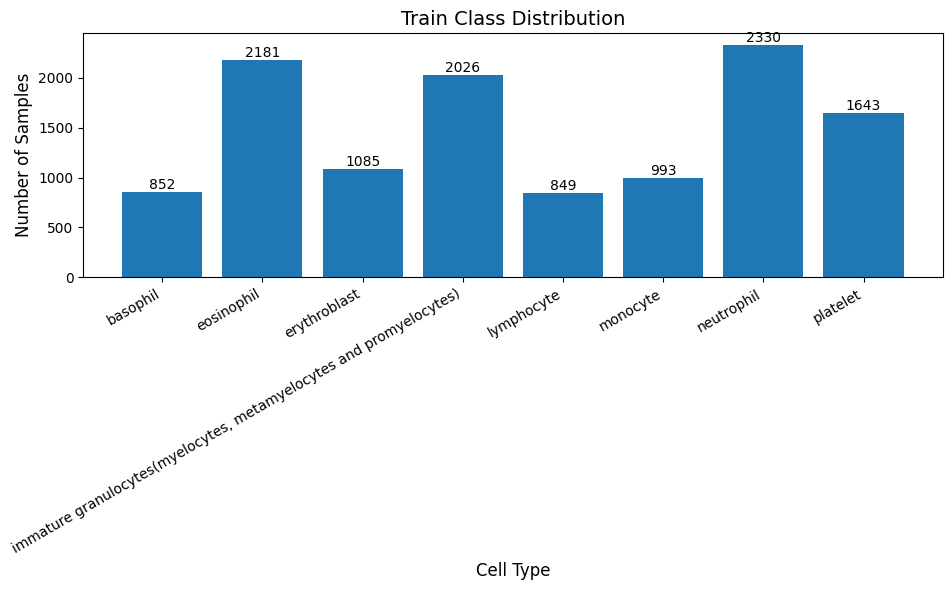

In [28]:
plt.figure(figsize=(10, 6))

classes = sorted(set(train_labels))
counts = [np.sum(train_labels == c) for c in classes]
labels = [info['label'][str(c)] for c in classes]

#bar plot
bars = plt.bar(classes, counts)

#x-axis labels
plt.xticks(classes, labels, rotation=30, ha='right')

#titles and labels
plt.title("Train Class Distribution", fontsize=14)
plt.ylabel("Number of Samples", fontsize=12)
plt.xlabel("Cell Type", fontsize=12)

#labels on top of bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2,
        height,
        f'{int(height)}',
        ha='center',
        va='bottom',
        fontsize=10)
plt.tight_layout()
plt.show()

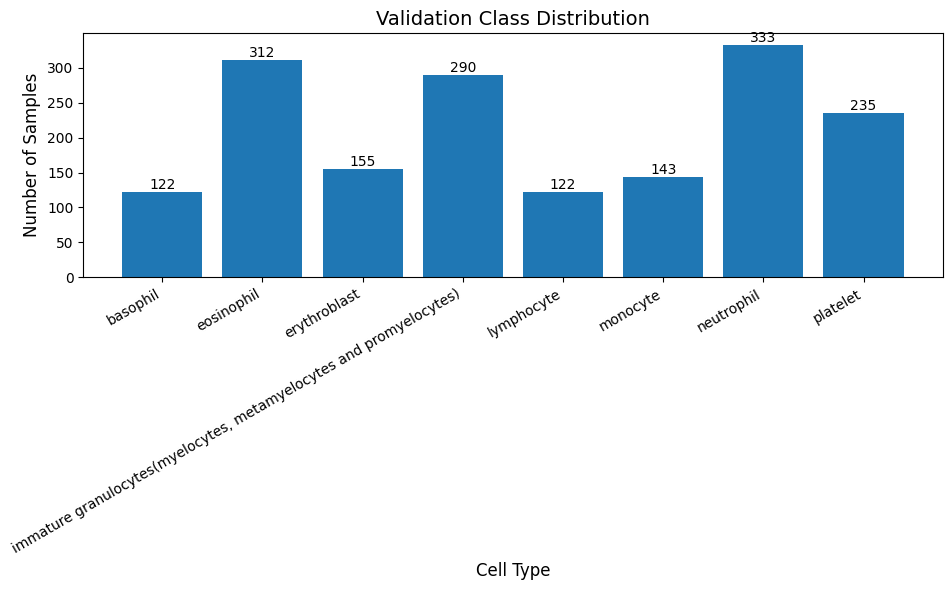

In [29]:
plt.figure(figsize=(10, 6))
classes = sorted(set(val_labels))
counts = [np.sum(val_labels == c) for c in classes]
labels = [info['label'][str(c)] for c in classes]

#plot
bars = plt.bar(classes, counts)

#x-axis labels
plt.xticks(classes, labels, rotation=30, ha='right')

#titles and labels
plt.title("Validation Class Distribution", fontsize=14)
plt.ylabel("Number of Samples", fontsize=12)
plt.xlabel("Cell Type", fontsize=12)

#labels on top of bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2,
        height,
        f'{int(height)}',
        ha='center',
        va='bottom',
        fontsize=10)
plt.tight_layout()
plt.show()

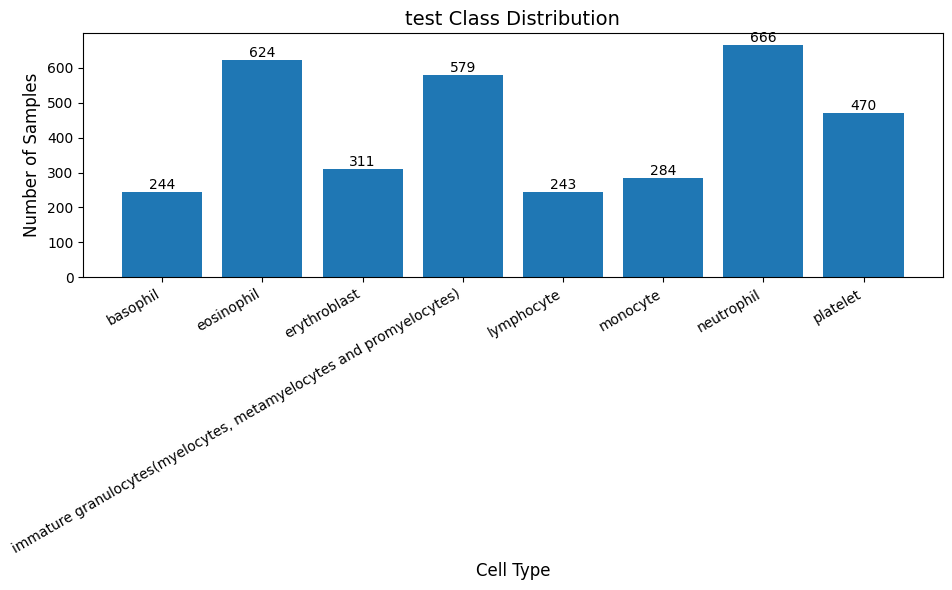

In [30]:
plt.figure(figsize=(10, 6))  # bigger figure

classes = sorted(set(test_labels))
counts = [np.sum(test_labels == c) for c in classes]
labels = [info['label'][str(c)] for c in classes]

#bar plot
bars = plt.bar(classes, counts)

#x-axis labels
plt.xticks(classes, labels, rotation=30, ha='right')

#titles and labels
plt.title("test Class Distribution", fontsize=14)
plt.ylabel("Number of Samples", fontsize=12)
plt.xlabel("Cell Type", fontsize=12)

#value labels on top of bars
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f'{int(height)}',
        ha='center',
        va='bottom',
        fontsize=10)
plt.tight_layout()
plt.show()

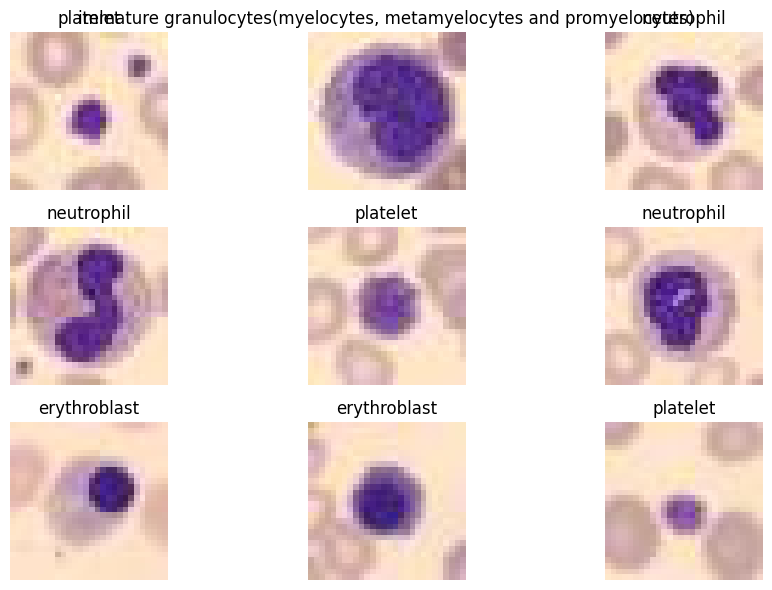

In [31]:
#sample images
def show_samples(dataset, num_samples=9):
    plt.figure(figsize=(10, 6))
    for i in range(num_samples):
        img, label = dataset[i]
        plt.subplot(3, 3, i+1)
        plt.imshow(img.permute(1, 2, 0) * 0.5 + 0.5)
        plt.title(info['label'][str(int(label.item()))])
        plt.axis('off')
    plt.tight_layout()
    plt.show()

show_samples(train_dataset)

In [32]:
import torch
import torch.nn as nn
import torch.optim as optim
import math
import numpy as np
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
from medmnist import BloodMNIST
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import torchvision.utils as vutils

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [33]:
#transform
transform = transforms.Compose([transforms.ToTensor(),transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])])
full_dataset = BloodMNIST(split="train", transform=transform, download=True)

In [34]:
#weight initialization
def weights_init(m):
    cname = m.__class__.__name__
    if "Conv" in cname:
        nn.init.normal_(m.weight.data, 0.0, 0.02)
    elif "BatchNorm" in cname:
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0)

In [35]:
#generator
class Generator(nn.Module):
    def __init__(self, latent_dim=100, channels=3, ngf=64):
        super().__init__()
        self.model = nn.Sequential(
            nn.ConvTranspose2d(latent_dim, ngf*4, 4, 1, 0, bias=False),
            nn.BatchNorm2d(ngf*4), nn.ReLU(True),
            nn.ConvTranspose2d(ngf*4, ngf*2, 3, 2, 1, bias=False),
            nn.BatchNorm2d(ngf*2), nn.ReLU(True),
            nn.ConvTranspose2d(ngf*2, ngf,   4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf),   nn.ReLU(True),
            nn.ConvTranspose2d(ngf, channels, 4, 2, 1, bias=False),
            nn.Tanh())
    def forward(self, z): return self.model(z)

In [36]:
#discriminator
class Discriminator(nn.Module):
    def __init__(self, channels=3, ndf=64):
        super().__init__()
        self.model = nn.Sequential(
            nn.Conv2d(channels, ndf,   4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(ndf,   ndf*2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf*2), nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(ndf*2, ndf*4, 3, 2, 1, bias=False),
            nn.BatchNorm2d(ndf*4), nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(ndf*4, 1,     4, 1, 0, bias=False),
            nn.Sigmoid()
        )
    def forward(self, x): return self.model(x).view(-1, 1)

In [37]:
#hyperparameter tuning
param_grid = {
    "lr":[0.0002, 0.0001],
    "latent_dim":[64, 100, 128],
    "batch_size":[64, 128],}
tune_eopchs = 5
real_label= 0.9
target=math.log(2)# ln(2) ≈ 0.693 — Nash equilibrium
results=[]
total_runs=(len(param_grid["lr"]) *
              len(param_grid["latent_dim"]) *
              len(param_grid["batch_size"]))
run = 0

In [38]:
#tuning loop
for lr in param_grid["lr"]:
    for latent_dim in param_grid["latent_dim"]:
        for batch_size in param_grid["batch_size"]:
            run += 1
            print(f"[{run:2d}/{total_runs}] LR={lr}  Z={latent_dim}  BS={batch_size} … ",
                  end="", flush=True)

            dataloader = DataLoader(full_dataset, batch_size=batch_size,
                                    shuffle=True, drop_last=True)

            G = Generator(latent_dim).to(device);     G.apply(weights_init)
            D = Discriminator().to(device);            D.apply(weights_init)

            criterion= nn.BCELoss()
            optimizer_G = optim.Adam(G.parameters(), lr=lr, betas=(0.5, 0.999))
            optimizer_D = optim.Adam(D.parameters(), lr=lr, betas=(0.5, 0.999))

            for epoch in range(tune_eopchs):
                for real_images, _ in dataloader:
                    real_images = real_images.to(device)
                    b           = real_images.size(0)
                    real_lbl    = torch.full((b, 1), real_label, device=device)
                    fake_lbl    = torch.zeros(b, 1,              device=device)

                    # D step
                    optimizer_D.zero_grad()
                    loss_real = criterion(D(real_images), real_lbl)
                    z         = torch.randn(b, latent_dim, 1, 1, device=device)
                    fake_imgs = G(z)
                    loss_fake = criterion(D(fake_imgs.detach()), fake_lbl)
                    d_loss    = loss_real + loss_fake
                    d_loss.backward(); optimizer_D.step()

                    # G step
                    optimizer_G.zero_grad()
                    z=torch.randn(b, latent_dim, 1, 1, device=device)
                    fake_imgs=G(z)
                    g_loss=criterion(D(fake_imgs), real_lbl)
                    g_loss.backward(); optimizer_G.step()

            d_val=d_loss.item()
            g_val=g_loss.item()
            score=abs(d_val-target) # lower = closer to equilibrium
            results.append({"lr":lr,"latent_dim": latent_dim,"batch_size":batch_size,"D_loss":d_val,"G_loss":g_val,"score":score})
            print(f"D={d_val:.4f}G={g_val:.4f}|D−ln2|={score:.4f}")

[ 1/12] LR=0.0002  Z=64  BS=64 … D=0.7066G=1.3415|D−ln2|=0.0134
[ 2/12] LR=0.0002  Z=64  BS=128 … D=0.7588G=1.8193|D−ln2|=0.0657
[ 3/12] LR=0.0002  Z=100  BS=64 … D=0.7718G=1.6542|D−ln2|=0.0787
[ 4/12] LR=0.0002  Z=100  BS=128 … D=0.7080G=1.5999|D−ln2|=0.0148
[ 5/12] LR=0.0002  Z=128  BS=64 … D=0.7025G=1.5434|D−ln2|=0.0094
[ 6/12] LR=0.0002  Z=128  BS=128 … D=0.8774G=2.4951|D−ln2|=0.1842
[ 7/12] LR=0.0001  Z=64  BS=64 … D=0.7889G=1.5596|D−ln2|=0.0958
[ 8/12] LR=0.0001  Z=64  BS=128 … D=0.7419G=1.6929|D−ln2|=0.0488
[ 9/12] LR=0.0001  Z=100  BS=64 … D=0.6968G=1.6988|D−ln2|=0.0037
[10/12] LR=0.0001  Z=100  BS=128 … D=0.7556G=1.6789|D−ln2|=0.0625
[11/12] LR=0.0001  Z=128  BS=64 … D=0.5835G=2.3115|D−ln2|=0.1097
[12/12] LR=0.0001  Z=128  BS=128 … D=0.5200G=2.9121|D−ln2|=0.1732


In [39]:
#results
results.sort(key=lambda x: x["score"])
best = results[0]

print("Hyperparameter Results (sorted best → worst)")
print(f"  {'Rank':<5} {'LR':<8} {'Z':<6} {'BS':<5} "
      f"{'D_loss':<9} {'G_loss':<9} {'|D−ln2|':<9} {'Verdict'}")
for i, r in enumerate(results, 1):
    if r["D_loss"] < 0.5:
        verdict = "D too strong → collapse risk"
    elif r["D_loss"] > 0.85:
        verdict = "D too weak"
    else:
        verdict = "← BEST" if i == 1 else "good"
    print(f"  {i:<5} {r['lr']:<8} {r['latent_dim']:<6} {r['batch_size']:<5} "
          f"{r['D_loss']:<9.4f} {r['G_loss']:<9.4f} {r['score']:<9.4f} {verdict}")

print(f"\n  Best config: LR={best['lr']}, Z={best['latent_dim']}, "
      f"BS={best['batch_size']}")
print(f"  D_loss={best['D_loss']:.4f}  G_loss={best['G_loss']:.4f}")

Hyperparameter Results (sorted best → worst)
  Rank  LR       Z      BS    D_loss    G_loss    |D−ln2|   Verdict
  1     0.0001   100    64    0.6968    1.6988    0.0037    ← BEST
  2     0.0002   128    64    0.7025    1.5434    0.0094    good
  3     0.0002   64     64    0.7066    1.3415    0.0134    good
  4     0.0002   100    128   0.7080    1.5999    0.0148    good
  5     0.0001   64     128   0.7419    1.6929    0.0488    good
  6     0.0001   100    128   0.7556    1.6789    0.0625    good
  7     0.0002   64     128   0.7588    1.8193    0.0657    good
  8     0.0002   100    64    0.7718    1.6542    0.0787    good
  9     0.0001   64     64    0.7889    1.5596    0.0958    good
  10    0.0001   128    64    0.5835    2.3115    0.1097    good
  11    0.0001   128    128   0.5200    2.9121    0.1732    good
  12    0.0002   128    128   0.8774    2.4951    0.1842    D too weak

  Best config: LR=0.0001, Z=100, BS=64
  D_loss=0.6968  G_loss=1.6988


In [40]:
#retraining
print("Retraining with best config for 50 epochs")
torch.manual_seed(42)
dataloader=DataLoader(full_dataset, batch_size=best["batch_size"],shuffle=True, drop_last=True)
latent_dim=best["latent_dim"]
G=Generator(latent_dim).to(device);G.apply(weights_init)
D=Discriminator().to(device);D.apply(weights_init)
criterion= nn.BCELoss()
optimizer_G = optim.Adam(G.parameters(), lr=best["lr"], betas=(0.5, 0.999))
optimizer_D = optim.Adam(D.parameters(), lr=best["lr"], betas=(0.5, 0.999))

fixed_noise=torch.randn(64, latent_dim,1,1,device=device)
G_losses,D_losses =[],[]
EPOCHS=50

for epoch in range(EPOCHS):
    g_run = d_run = 0.0

    for real_images,_ in dataloader:
        real_images=real_images.to(device)
        b=real_images.size(0)
        real_labels=torch.full((b, 1),real_label, device=device)
        fake_labels = torch.zeros(b, 1,              device=device)

        optimizer_D.zero_grad()
        real_loss = criterion(D(real_images), real_labels)
        z         = torch.randn(b, latent_dim, 1, 1, device=device)
        fake_imgs = G(z)
        fake_loss = criterion(D(fake_imgs.detach()), fake_labels)
        d_loss    = real_loss + fake_loss
        d_loss.backward(); optimizer_D.step()

        optimizer_G.zero_grad()
        z         = torch.randn(b, latent_dim, 1, 1, device=device)
        fake_imgs = G(z)
        g_loss    = criterion(D(fake_imgs), real_labels)
        g_loss.backward(); optimizer_G.step()

        d_run += d_loss.item()
        g_run += g_loss.item()

    n = len(dataloader)
    G_losses.append(g_run / n)
    D_losses.append(d_run / n)

    if (epoch + 1) % 10 == 0 or epoch == 0:
        print(f"  Epoch [{epoch+1:3d}/{EPOCHS}] | "
              f"D: {D_losses[-1]:.4f} | G: {G_losses[-1]:.4f}")

Retraining with best config for 50 epochs
  Epoch [  1/50] | D: 0.5084 | G: 3.2664
  Epoch [ 10/50] | D: 0.7738 | G: 1.8720
  Epoch [ 20/50] | D: 0.7735 | G: 1.9959
  Epoch [ 30/50] | D: 0.6820 | G: 2.1699
  Epoch [ 40/50] | D: 0.5787 | G: 2.4834
  Epoch [ 50/50] | D: 0.6103 | G: 2.6265


In [41]:
#final loss curve
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(G_losses, color="#e74c3c", lw=1.8, label="Generator")
ax.plot(D_losses, color="#3498db", lw=1.8, label="Discriminator")
ax.axhline(target, color="#aaa", ls="--", lw=1.2,
           label=f"ln(2) ≈ {target:.3f}")
ax.set_xlabel("Epoch"); ax.set_ylabel("BCE Loss")
ax.set_title(f"BloodMNIST DCGAN — Best config: "
             f"LR={best['lr']}, Z={best['latent_dim']}, BS={best['batch_size']}")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [42]:
#fake vs real comparison
G.eval()
with torch.no_grad():
    fake_imgs = G(torch.randn(32, latent_dim, 1, 1, device=device)).cpu()
real_imgs  = next(iter(dataloader))[0][:32].cpu()
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
for ax, imgs, title in zip(axes,[real_imgs, fake_imgs],["Real images", "Generated images (DCGAN)"]):
    grid = vutils.make_grid(imgs, nrow=8, normalize=True, value_range=(-1, 1))
    ax.imshow(grid.permute(1, 2, 0).numpy())
    ax.set_title(title, fontsize=11)
    ax.axis("off")
plt.tight_layout()
plt.show()

In [43]:
!pip install torch-fidelity

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.6/85.6 kB 5.1 MB/s eta 0:00:00


In [44]:
from torch_fidelity import calculate_metrics
import os
from torchvision.utils import save_image

In [45]:
import os
from torchvision.utils import save_image

os.makedirs("real", exist_ok=True)
os.makedirs("fake", exist_ok=True)

#save REAL images
count = 0
for real_images, _ in dataloader:
    for img in real_images:
        save_image(img, f"real/{count}.png", normalize=True, value_range=(-1,1))
        count += 1
        if count >= 1000:   # use 1000 images for FID
            break
    if count >= 1000:
        break

#save FAKE images
G.eval()
count = 0

with torch.no_grad():
    while count < 1000:
        z = torch.randn(32, latent_dim, 1, 1, device=device)
        fake_images = G(z)

        for img in fake_images:
            save_image(img, f"fake/{count}.png", normalize=True, value_range=(-1,1))
            count += 1
            if count >= 1000:
                break

In [46]:
from torch_fidelity import calculate_metrics
metrics = calculate_metrics(
    input1="real",
    input2="fake",
    cuda=True,
    fid=True)
print("FID score:", metrics["frechet_inception_distance"])

Creating feature extractor "inception-v3-compat" with features ['2048']
Downloading: "https://github.com/toshas/torch-fidelity/releases/download/v0.2.0/weights-inception-2015-12-05-6726825d.pth" to /root/.cache/torch/hub/checkpoints/weights-inception-2015-12-05-6726825d.pth
100%|██████████| 91.2M/91.2M [00:01<00:00, 94.6MB/s]
Extracting statistics from input 1
Looking for samples non-recursivelty in "real" with extensions png,jpg,jpeg
Found 1000 samples
Processing samples
Extracting statistics from input 2
Looking for samples non-recursivelty in "fake" with extensions png,jpg,jpeg
Found 1000 samples
Processing samples


FID score: 168.5873408138633


Frechet Inception Distance: 168.5873


#**Extension**

In [47]:
#constants
IMG_SIZE   = 28
CHANNELS   = 3
N_CLASSES  = 8
LATENT_DIM = 100
EMBED_DIM  = 50        #class embedding size
BATCH_SIZE = 128
EPOCHS     = 100       #100 gives decent results; 200+ for publication quality
LR         = 0.0002
BETA1      = 0.5
REAL_LABEL = 0.9       #label smoothing
CLASS_NAMES = [ "Basophil","Eosinophil","Erythroblast","Immature Granulocyte","Lymphocyte","Monocyte","Neutrophil","Platelet"]

In [48]:
#weights
def weights_init(m):
    cname = m.__class__.__name__
    if "Conv" in cname:
        nn.init.normal_(m.weight.data, 0.0, 0.02)
    elif "BatchNorm" in cname:
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0)

In [49]:
#conditional generator
class ConditionalGenerator(nn.Module):
    def __init__(self, latent_dim=LATENT_DIM, n_classes=N_CLASSES,
                 embed_dim=EMBED_DIM, channels=CHANNELS, ngf=64):
        super().__init__()

        self.label_emb = nn.Embedding(n_classes, embed_dim)
        in_dim = latent_dim + embed_dim   # 150
        self.net = nn.Sequential(nn.ConvTranspose2d(in_dim, ngf * 4, 4, 1, 0, bias=False),
            nn.BatchNorm2d(ngf * 4),
            nn.ReLU(True),
            nn.ConvTranspose2d(ngf * 4, ngf * 2, 3, 2, 1, bias=False),
            nn.BatchNorm2d(ngf * 2),
            nn.ReLU(True),
            nn.ConvTranspose2d(ngf * 2, ngf, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf),
            nn.ReLU(True),
            nn.ConvTranspose2d(ngf, channels, 4, 2, 1, bias=False),
            nn.Tanh())

    def forward(self, z, labels):
        emb = self.label_emb(labels).unsqueeze(-1).unsqueeze(-1)
        x   = torch.cat([z, emb], dim=1)
        return self.net(x)

In [50]:
#conditional discriminator
class ConditionalDiscriminator(nn.Module):
    def __init__(self, n_classes=N_CLASSES, channels=CHANNELS,
                 img_size=IMG_SIZE, ndf=64):
        super().__init__()
        self.label_emb = nn.Embedding(n_classes, img_size * img_size)
        self.img_size  = img_size

        self.net = nn.Sequential(nn.Conv2d(channels + 1, ndf, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(ndf, ndf * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf * 2),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(ndf * 2, ndf * 4, 3, 2, 1, bias=False),
            nn.BatchNorm2d(ndf * 4),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(ndf * 4, 1, 4, 1, 0, bias=False),
            nn.Sigmoid())

    def forward(self, x, labels):
        # label → (B, 1, img_size, img_size) spatial map
        lbl_map = self.label_emb(labels).view(
            -1, 1, self.img_size, self.img_size
        )
        inp = torch.cat([x, lbl_map], dim=1)   # (B, 4, 28, 28)
        return self.net(inp).view(-1, 1)

In [51]:
import torch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [52]:
G = ConditionalGenerator().to(device)
D = ConditionalDiscriminator().to(device)

#custom weight initialization to both models
G.apply(weights_init)
D.apply(weights_init)

#total number of trainable parameters in both models
print(f"Generator     params: {sum(p.numel() for p in G.parameters()):,}")
print(f"Discriminator params: {sum(p.numel() for p in D.parameters()):,}")

Generator     params: 1,044,752
Discriminator params: 441,216


In [53]:
#loss, optimisers
criterion  = nn.BCELoss()
optimizer_G = torch.optim.Adam(G.parameters(), lr=LR, betas=(BETA1, 0.999))
optimizer_D = torch.optim.Adam(D.parameters(), lr=LR, betas=(BETA1, 0.999))

fixed_noise  = torch.randn(N_CLASSES * 8, LATENT_DIM, 1, 1, device=device)
fixed_labels = torch.tensor([c for c in range(N_CLASSES) for _ in range(8)],dtype=torch.long, device=device) # shape (64,) : 8 samples × 8 classes = 64 images


In [54]:
# training loop
G_losses, D_losses = [], []

print(f"Training cGAN — {EPOCHS} epochs")
for epoch in range(EPOCHS):
    g_run = d_run = 0.0

    for real_imgs,labels in dataloader:
        real_imgs=real_imgs.to(device)
        labels=labels.squeeze().long().to(device)
        b=real_imgs.size(0)
        real_lbl=torch.full((b, 1), REAL_LABEL, device=device)
        fake_lbl=torch.zeros(b, 1, device=device)

        #discriminator
        optimizer_D.zero_grad()
        # real images with their true labels
        real_loss=criterion(D(real_imgs, labels), real_lbl)

        # fake images with the same labels (G must fool D on the correct class)
        z=torch.randn(b, LATENT_DIM, 1, 1, device=device)
        fake_imgs=G(z, labels)
        fake_loss=criterion(D(fake_imgs.detach(), labels), fake_lbl)
        d_loss=real_loss + fake_loss
        d_loss.backward()
        optimizer_D.step()

        #generator
        optimizer_G.zero_grad()
        z=torch.randn(b, LATENT_DIM, 1, 1, device=device)
        fake_imgs=G(z, labels)
        g_loss=criterion(D(fake_imgs, labels), real_lbl)
        g_loss.backward()
        optimizer_G.step()
        d_run+=d_loss.item()
        g_run+=g_loss.item()

    n=len(dataloader)
    G_losses.append(g_run / n)
    D_losses.append(d_run / n)

    print(f"Epoch [{epoch+1:3d}/{EPOCHS}] | "
          f"D: {D_losses[-1]:.4f} | G: {G_losses[-1]:.4f}")

Training cGAN — 100 epochs
Epoch [  1/100] | D: 1.2181 | G: 1.8782
Epoch [  2/100] | D: 1.2013 | G: 1.7129
Epoch [  3/100] | D: 1.0834 | G: 1.9216
Epoch [  4/100] | D: 1.0893 | G: 1.9931
Epoch [  5/100] | D: 1.1166 | G: 1.9485
Epoch [  6/100] | D: 1.1574 | G: 1.8221
Epoch [  7/100] | D: 1.1651 | G: 1.7179
Epoch [  8/100] | D: 1.1346 | G: 1.7353
Epoch [  9/100] | D: 1.1164 | G: 1.7224
Epoch [ 10/100] | D: 1.0890 | G: 1.7663
Epoch [ 11/100] | D: 1.0335 | G: 1.7556
Epoch [ 12/100] | D: 0.9752 | G: 1.8517
Epoch [ 13/100] | D: 0.9261 | G: 1.8794
Epoch [ 14/100] | D: 0.9266 | G: 2.0358
Epoch [ 15/100] | D: 0.8625 | G: 2.0716
Epoch [ 16/100] | D: 0.8652 | G: 2.0606
Epoch [ 17/100] | D: 0.8629 | G: 2.2013
Epoch [ 18/100] | D: 0.8343 | G: 2.1847
Epoch [ 19/100] | D: 0.7724 | G: 2.3337
Epoch [ 20/100] | D: 0.7912 | G: 2.4054
Epoch [ 21/100] | D: 0.7533 | G: 2.4266
Epoch [ 22/100] | D: 0.7586 | G: 2.4191
Epoch [ 23/100] | D: 0.7340 | G: 2.4299
Epoch [ 24/100] | D: 0.7160 | G: 2.5160
Epoch [ 25/10

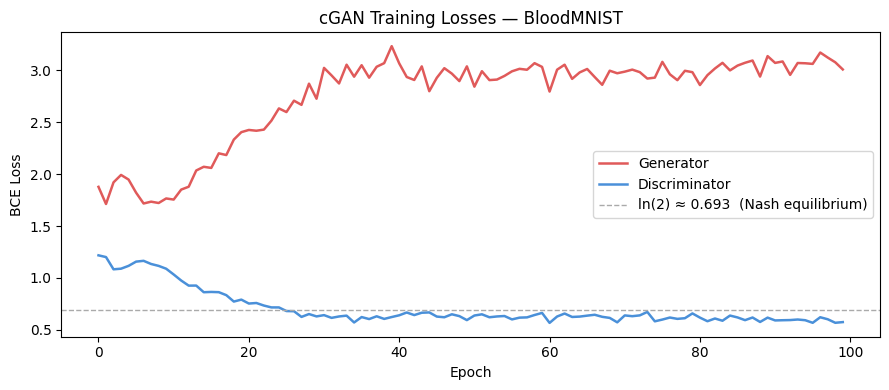

In [62]:
#loss curves
plt.figure(figsize=(9, 4))
plt.plot(G_losses, color="#e05a5a", linewidth=1.8, label="Generator")
plt.plot(D_losses, color="#4a90d9", linewidth=1.8, label="Discriminator")
plt.axhline(np.log(2), color="#aaa", linestyle="--", linewidth=1,label="ln(2) ≈ 0.693  (Nash equilibrium)")
plt.xlabel("Epoch"); plt.ylabel("BCE Loss")
plt.title("cGAN Training Losses — BloodMNIST")
plt.legend()
plt.tight_layout()
plt.show()

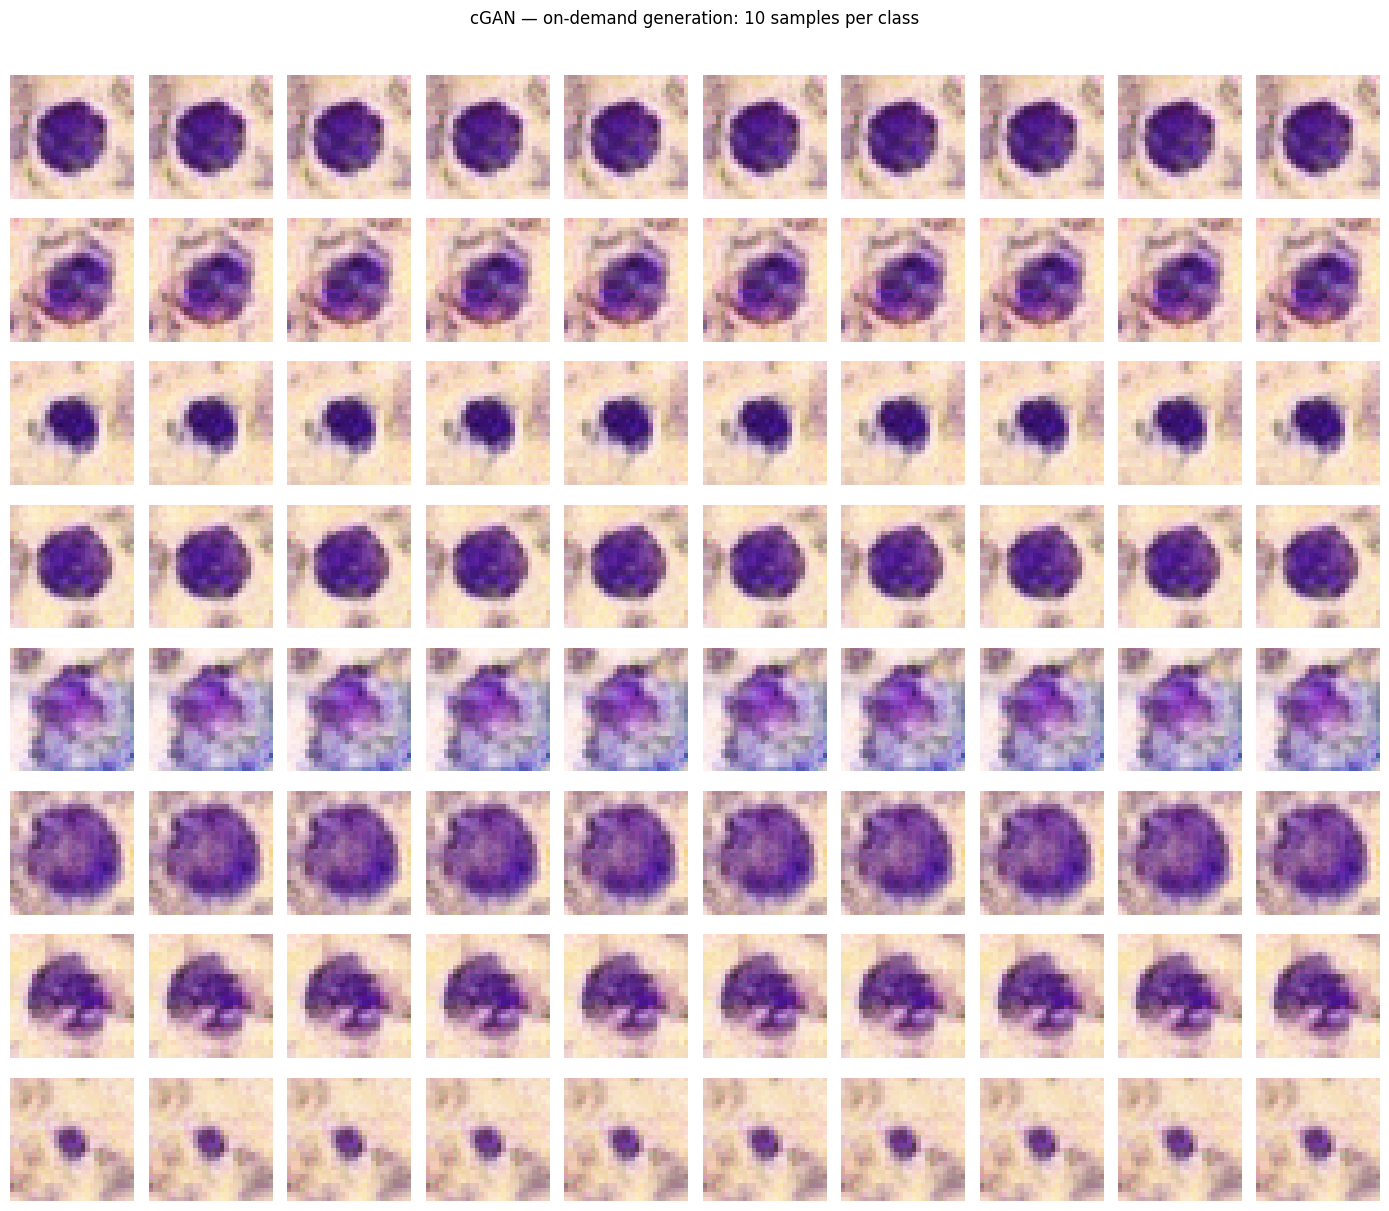

In [63]:
#generation per class

G.eval()
N_SAMPLES = 10   #samples per class
fig, axes = plt.subplots(N_CLASSES, N_SAMPLES,figsize=(N_SAMPLES * 1.4, N_CLASSES * 1.5))
fig.suptitle("cGAN — on-demand generation: 10 samples per class",fontsize=12, y=1.01)
COLORS = ["#e05a5a","#e07a30","#d4a017","#3cb371",
          "#4a90d9","#9b59b6","#1abc9c","#e8b84b"]
with torch.no_grad():
    for cls_idx in range(N_CLASSES):
        z   = torch.randn(N_SAMPLES, LATENT_DIM, 1, 1, device=device)
        lbl = torch.full((N_SAMPLES,), cls_idx, dtype=torch.long, device=device)
        imgs = G(z, lbl).cpu()
        imgs = (imgs * 0.5 + 0.5).clamp(0, 1)
        for col in range(N_SAMPLES):
            ax = axes[cls_idx][col]
            ax.imshow(imgs[col].permute(1, 2, 0).numpy())
            ax.axis("off")
            # coloured border to identify class
            for spine in ax.spines.values():
                spine.set_visible(True)
                spine.set_edgecolor(COLORS[cls_idx])
                spine.set_linewidth(2.0)

        # class name as row ylabel on the leftmost cell
        axes[cls_idx][0].set_ylabel(
            CLASS_NAMES[cls_idx], fontsize=8,
            color=COLORS[cls_idx], fontweight="bold",
            rotation=0, labelpad=90, va="center")
plt.tight_layout()
plt.show()

In [64]:
#generation from single class
def generate_class(generator, class_index, n=8,
                   latent_dim=LATENT_DIM, device=device):
    generator.eval()
    with torch.no_grad():
        z   = torch.randn(n, latent_dim, 1, 1, device=device)
        lbl = torch.full((n,), class_index, dtype=torch.long, device=device)
        imgs = generator(z, lbl).cpu()
    return (imgs * 0.5 + 0.5).clamp(0, 1)

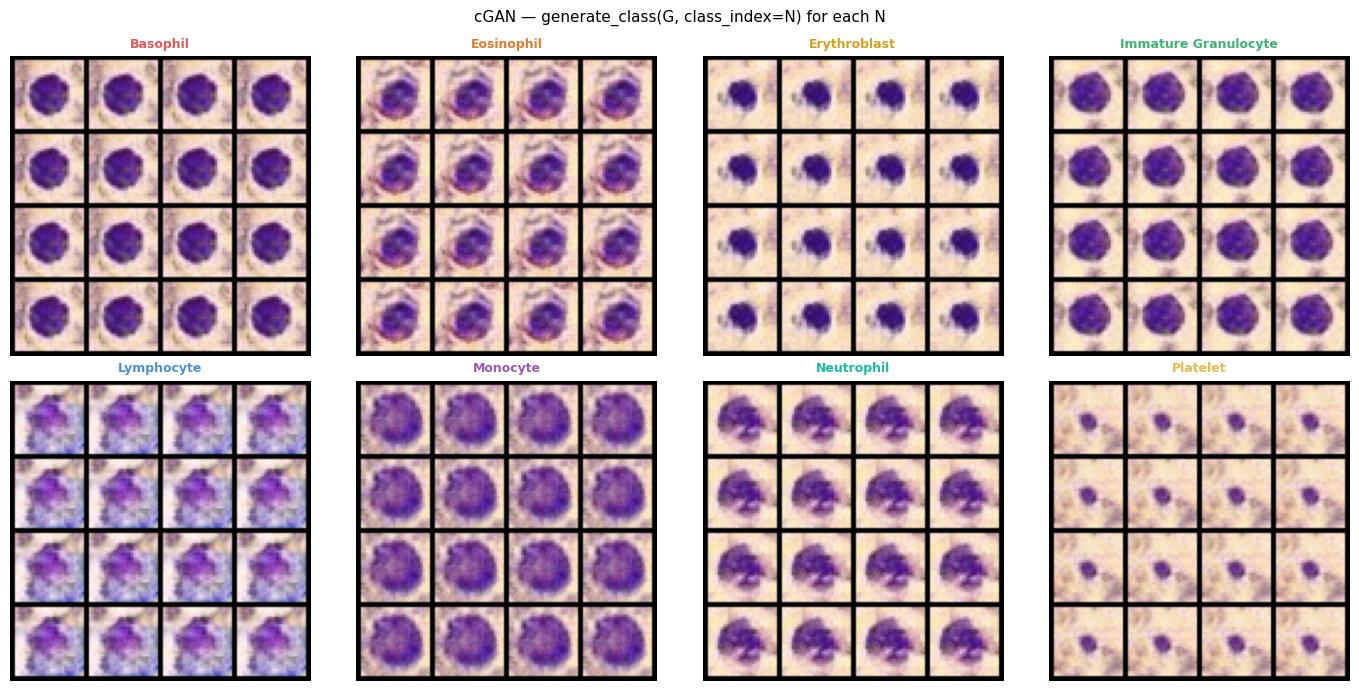

In [65]:
#generate each class individually
fig, axes = plt.subplots(2, 4, figsize=(14, 7))
axes = axes.ravel()
for cls_idx in range(N_CLASSES):
    imgs = generate_class(G, class_index=cls_idx, n=16)
    grid = vutils.make_grid(imgs, nrow=4, padding=2,normalize=False)   # already in [0,1]
    axes[cls_idx].imshow(grid.permute(1, 2, 0).numpy())
    axes[cls_idx].set_title(CLASS_NAMES[cls_idx],fontsize=9, color=COLORS[cls_idx],fontweight="bold")
    axes[cls_idx].axis("off")
plt.suptitle("cGAN — generate_class(G, class_index=N) for each N",fontsize=11)
plt.tight_layout()
plt.show()